In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter,filtfilt

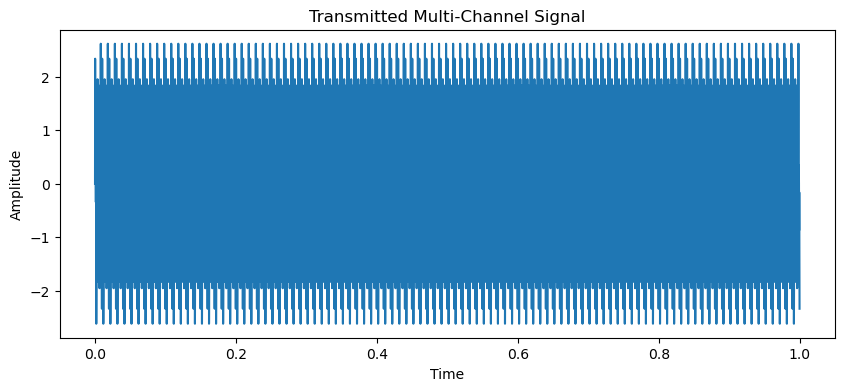

In [2]:
# Sampling parameters

fs = 5000
T = 1

t = np.arange(0,T,1/fs)


# Channel frequencies (simulating multiple RF channels)

frequencies = [400,900,1500]


# Generate multi-channel signal

signal = 0

for f in frequencies:
    
    signal += np.sin(2*np.pi*f*t)


plt.figure(figsize=(10,4))

plt.plot(t,signal)

plt.title("Transmitted Multi-Channel Signal")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

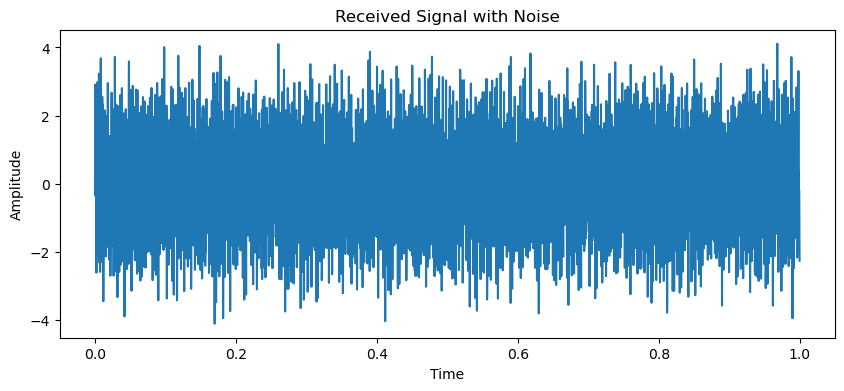

In [4]:


noise = np.random.normal(0,0.7,len(t))

received_signal = signal + noise


plt.figure(figsize=(10,4))

plt.plot(t,received_signal)

plt.title("Received Signal with Noise")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

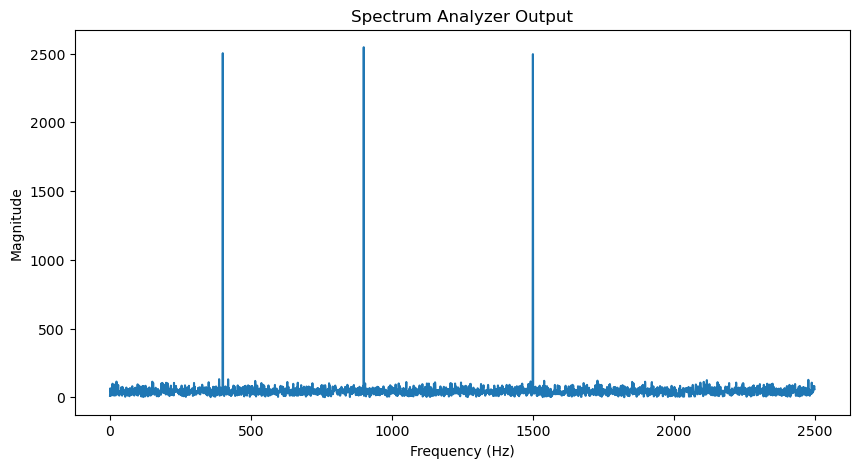

In [5]:
# FFT computation

fft_output = np.fft.fft(received_signal)

freq = np.fft.fftfreq(len(received_signal),1/fs)


# Take positive frequencies only

mask = freq >= 0

freq = freq[mask]

magnitude = np.abs(fft_output[mask])


plt.figure(figsize=(10,5))

plt.plot(freq,magnitude)

plt.title("Spectrum Analyzer Output")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.show()

In [6]:
# Detect peaks

peaks,_ = find_peaks(magnitude,height=500)


detected_freq = freq[peaks]


print("Detected Channels:")

for f in detected_freq:
    
    print(round(f,2),"Hz")

Detected Channels:
400.0 Hz
900.0 Hz
1500.0 Hz


Strongest Channel: 900.0 Hz


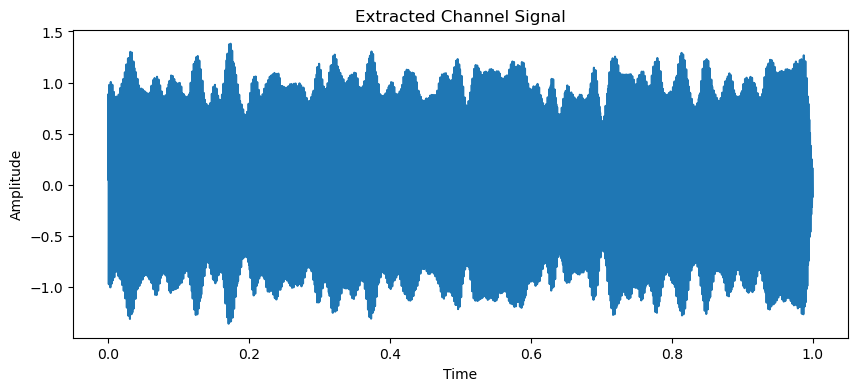

In [7]:
# Find strongest channel

peak_magnitudes = magnitude[peaks]

strongest_index = np.argmax(peak_magnitudes)

channel_freq = detected_freq[strongest_index]


print("Strongest Channel:",round(channel_freq,2),"Hz")


# Bandpass filter design

low = channel_freq - 50

high = channel_freq + 50


nyquist = fs/2

low = low/nyquist

high = high/nyquist


b,a = butter(4,[low,high],btype='band')


filtered_signal = filtfilt(b,a,received_signal)


plt.figure(figsize=(10,4))

plt.plot(t,filtered_signal)

plt.title("Extracted Channel Signal")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

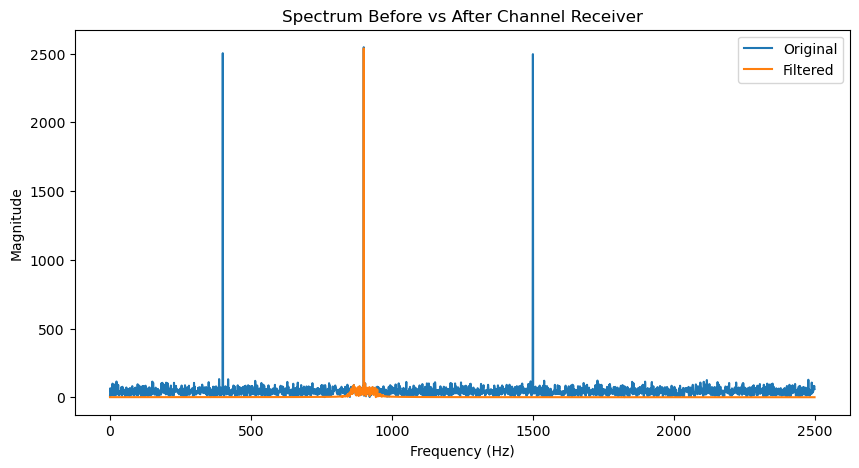

In [8]:
# FFT of filtered signal

filtered_fft = np.fft.fft(filtered_signal)

filtered_mag = np.abs(filtered_fft[mask])


plt.figure(figsize=(10,5))

plt.plot(freq,magnitude,label="Original")

plt.plot(freq,filtered_mag,label="Filtered")

plt.title("Spectrum Before vs After Channel Receiver")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.legend()

plt.show()

In [9]:
# Channel power

power = np.sum(filtered_signal**2)/len(filtered_signal)


print("Extracted Channel Power:",power)

Extracted Channel Power: 0.5323921914724213


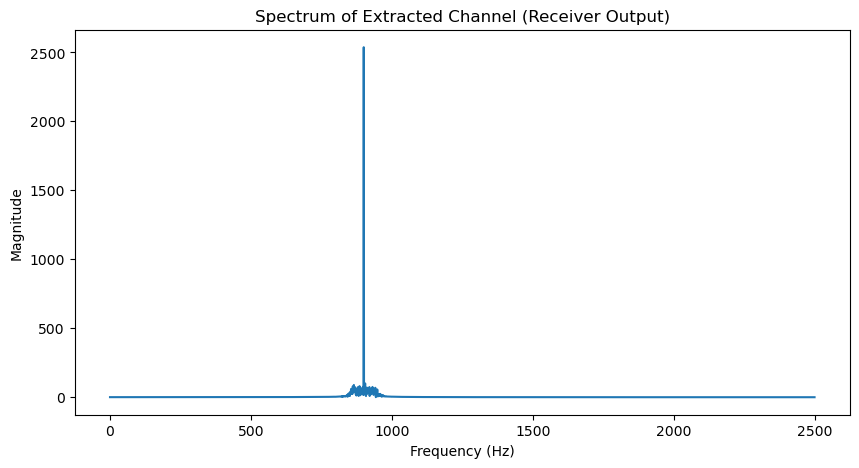

In [10]:
# Spectrum of extracted channel

plt.figure(figsize=(10,5))

plt.plot(freq,filtered_mag)

plt.title("Spectrum of Extracted Channel (Receiver Output)")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.show()

In [11]:
pip install pyrtlsdr

Note: you may need to restart the kernel to use updated packages.
